![Imgur](https://i.imgur.com/acSOZRh.png)

# Laboratorio n° 2: Redes Neuronales Convolucionales

**Asignatura:** Redes Neuronales Profundas  
**Bloque:** 2 — Visión por Computadora

---

## Introducción

Las **redes neuronales convolucionales** (CNNs) revolucionaron la visión por computadora. Su ingrediente clave es la **convolución**: una operación que aplica un pequeño filtro (*kernel*) deslizándolo sobre la imagen para detectar patrones locales. Al apilar muchas capas convolucionales, la red aprende a reconocer patrones cada vez más abstractos —desde bordes hasta objetos completos.

Este laboratorio está organizado de menor a mayor complejidad:

- Implementar la operación de convolución desde cero para entender su mecánica
- Dominar los tres parámetros que controlan las dimensiones: **kernel**, **padding** y **stride**
- Construir y entrenar una CNN completa sobre Fashion-MNIST
- Entender cómo se diseñan las Redes Neuronales Convolucionales Modernas con pytorch
---

## Instrucciones generales

- Completá el código en las celdas marcadas con `# Tu código aquí`.
- Respondé las preguntas de análisis en las celdas de texto (tipo Markdown).
- Para resolver cada ejercicio, consultá el material teórico.
- En la Sección A está **permitido usar bucles `for`**, porque el objetivo es ver explícitamente el mecanismo de la convolución. En el resto del laboratorio se aplica la regla habitual: sin bucles salvo indicación explícita.

In [ ]:
import torch
import torch.nn as nn
print(f"Versión de PyTorch: {torch.__version__}")

---
## Sección A: La operación de convolución

### Introducción a la convolución

La **correlación cruzada** (que PyTorch llama "convolución") funciona deslizando un *kernel* $K$ de tamaño $k_H \times k_W$ sobre una imagen $X$. En cada posición $(i, j)$, el resultado es:

$$Y[i,\, j] = \sum_{m=0}^{k_H-1} \sum_{n=0}^{k_W-1} X[i+m,\, j+n] \cdot K[m,\, n]$$

Sin padding ni stride, la salida tiene forma:

$$H_{out} = H_{in} - k_H + 1 \qquad W_{out} = W_{in} - k_W + 1$$

El kernel determina **qué tipo de característica se detecta**: bordes, texturas, esquinas, etc. Durante el entrenamiento, PyTorch aprende los valores del kernel automáticamente.

### Ejercicio 1 — Correlación cruzada manual

**Objetivo:** Entender paso a paso cómo un kernel recorre la imagen y produce el mapa de características.

**Enunciado:**

1. Implementá la función `corr2d(X, K)` que calcula la correlación cruzada 2D entre un tensor de entrada `X` de forma `(H, W)` y un kernel `K` de forma `(kH, kW)`. En este ejercicio está **permitido usar bucles `for`**.
2. Creá una imagen sintética de `6 × 6` píxeles: la mitad inferior (filas 3 a 5) igual a `1.0`, la mitad superior igual a `0.0` (una transición horizontal abrupta).
3. Aplicá el siguiente kernel de **detección de bordes horizontales** (Sobel vertical):

$$K = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix}$$

4. Imprimí el tensor de entrada y el mapa de características resultante.
5. Verificá que la forma de la salida coincide con la fórmula: $H_{out} = H_{in} - k_H + 1$.

> **Pista:** Dentro de `corr2d`, iterá con `for i in range(H_out)` y `for j in range(W_out)`. En cada posición, usá slicing para extraer la ventana `X[i:i+kH, j:j+kW]`, multiplicala elemento a elemento con `K` y sumá con `.sum()`.

In [24]:
def corr2d(X, K):
    """
    Calcula la correlación cruzada 2D.

    Parámetros:
    X (Tensor): tensor de entrada, forma (H, W)
    K (Tensor): kernel, forma (kH, kW)

    Retorna:
    Y (Tensor): mapa de características, forma (H-kH+1, W-kW+1)
    """
    H, W = X.shape
    kH, kW = K.shape

    H_out = H - kH + 1
    W_out = W - kW + 1

    Y = torch.zeros((H_out, W_out))

    for i in range(H_out):
        for j in range(W_out):
            ventana = X[i:i+kH, j:j+kW]
            Y[i, j] = (ventana * K).sum()

    return Y

**Pregunta de análisis:**

¿Por qué la operación se llama "correlación cruzada" y no "convolución"? ¿Qué diferencia matemática hay entre ambas? ¿Importa esa diferencia cuando el kernel se aprende durante el entrenamiento?

La diferencia es que la convolución matemática requiere rotar el kernel 180° antes de operar, mientras que la correlación cruzada lo aplica directamente.



En la práctica, esto no cambia el resultado en redes neuronales, porque los valores del kernel no están fijos, sino que se aprenden durante el entrenamiento. Por eso, si fuera necesario un kernel invertido, la red puede ajustarlo por sí sola sin necesidad de rotarlo previamente.


### Ejercicio 2 — Kernels con significado

**Objetivo:** Observar cómo distintos kernels preestablecidos transforman una misma imagen para desarrollar intuición sobre qué tipo de patrones detecta cada uno.

**Enunciado:**

Usarás `nn.Conv2d` para aplicar tres kernels distintos sobre una imagen sintética de `9 × 9` píxeles con una **franja horizontal blanca** en el centro (filas 4 y 5 iguales a `1.0`, el resto `0.0`).

| Kernel | Valores |
|---|---|
| Identidad | $\begin{bmatrix}0&0&0\\0&1&0\\0&0&0\end{bmatrix}$ |
| Bordes horizontales | $\begin{bmatrix}-1&-2&-1\\0&0&0\\1&2&1\end{bmatrix}$ |
| Suavizado Gaussiano | $\dfrac{1}{16}\begin{bmatrix}1&2&1\\2&4&2\\1&2&1\end{bmatrix}$ |

Para cada kernel:

1. Creá una capa `nn.Conv2d(1, 1, kernel_size=3, bias=False)` y asignale los pesos con `conv.weight[0, 0] = K` dentro de un bloque `with torch.no_grad()`.
2. Pasá la imagen por la capa y guardá la salida (usá `.detach()` para imprimirla).
3. Imprimí la salida con sus valores redondeados a 2 decimales y su forma (shape).

> **Pista:** `nn.Conv2d` espera tensores de forma `(N, C, H, W)`. Creá la imagen directamente como `torch.zeros(1, 1, 9, 9)` y asignale los valores a `img[0, 0, 4:6, :]`.

>  **Nota:** Al ver valores negativos en la salida podés notar que este resultado ya dejó de ser una "imagen" para convertirse en un **mapa de características**. El signo (positivo o negativo) no es un error de rango, sino que  **codifica información útil**: nos indica la dirección del contraste espacial (si el contorno del objeto pasó de oscuro a claro, o de claro a oscuro).


In [25]:
import torch
import torch.nn as nn

img = torch.zeros(1, 1, 9, 9)
img[0, 0, 4:6, :] = 1.0

K_identidad = torch.tensor([
    [0., 0., 0.],
    [0., 1., 0.],
    [0., 0., 0.]
])

K_bordes = torch.tensor([
    [-1., -2., -1.],
    [ 0.,  0.,  0.],
    [ 1.,  2.,  1.]
])

K_gauss = (1/16) * torch.tensor([
    [1., 2., 1.],
    [2., 4., 2.],
    [1., 2., 1.]
])

kernels = [
    ("Identidad", K_identidad),
    ("Bordes horizontales", K_bordes),
    ("Suavizado Gaussiano", K_gauss)
]

for nombre, K in kernels:
    conv = nn.Conv2d(1, 1, kernel_size=3, bias=False)

    with torch.no_grad():
        conv.weight[0, 0] = K

    salida = conv(img).detach()

    print(f"\n{nombre}")
    print(torch.round(salida[0, 0] * 100) / 100)
    print(salida.shape)


Identidad
tensor([[0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.]])
torch.Size([1, 1, 7, 7])

Bordes horizontales
tensor([[ 0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 4.,  4.,  4.,  4.,  4.,  4.,  4.],
        [ 4.,  4.,  4.,  4.,  4.,  4.,  4.],
        [-4., -4., -4., -4., -4., -4., -4.],
        [-4., -4., -4., -4., -4., -4., -4.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.]])
torch.Size([1, 1, 7, 7])

Suavizado Gaussiano
tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.2500, 0.2500, 0.2500],
        [0.7500, 0.7500, 0.7500, 0.7500, 0.7500, 0.7500, 0.7500],
        [0.7500, 0.7500, 0.7500, 0.7500, 0.7500, 0

**Pregunta de análisis:**

Describí en tus palabras qué detecta cada kernel:
- **Identidad:** ¿qué ocurre con la imagen?
- **Bordes horizontales:** ¿dónde aparecen valores distintos de cero en la salida? ¿Por qué precisamente ahí?
- **Suavizado Gaussiano:** ¿qué efecto produce sobre la franja y para qué sirve en el procesamiento de imágenes?

**Identidad:**  
La imagen queda prácticamente igual. No cambia la franja porque el kernel solo copia el valor del centro.

**Bordes horizontales:**  
Aparecen valores en los bordes de la franja, justo donde pasa de negro a blanco y de blanco a negro. Ahí es donde hay cambio, por eso el kernel responde en esas zonas.

**Suavizado Gaussiano:**  
La franja se hace más suave, no es tan marcada. En lugar de pasar directo de 0 a 1, aparecen valores intermedios. Esto sirve para suavizar la imagen y sacar ruido.

### Ejercicio 3 — Aprender un kernel con gradiente descendente

**Objetivo:** Mostrar que los pesos de una `Conv2d` son parámetros entrenables: una red puede *aprender* un kernel específico a partir de datos, usando el mismo mecanismo de retropropagación que cualquier otra capa.

**Contexto:**

El setup preescrito genera datos sintéticos: imágenes de entrada aleatorias `X_data` filtradas con un kernel de Laplaciano conocido (`kernel_verdadero`), produciendo `Y_data`. Tu tarea es entrenar una `Conv2d` con pesos iniciales aleatorios para que *recupere* ese kernel solo mirando pares (entrada, salida).

**Enunciado:**

1. Definí un modelo de una sola capa: `nn.Conv2d(1, 1, kernel_size=3, padding=1, bias=False)`.
2. Definí una función de pérdida `nn.MSELoss()` y un optimizador `torch.optim.SGD` con `lr=0.02`.
3. Escribí el bucle de entrenamiento para **150 épocas**. En cada época:
   - Calculá la predicción `Y_pred = conv(X_data)`.
   - Calculá la pérdida entre `Y_pred` e `Y_data`.
   - Ejecutá los tres pasos del gradiente: `zero_grad()`, `backward()`, `step()`.
4. Imprimí la pérdida cada 30 épocas para ver la convergencia.
5. Al finalizar, mostrá el kernel aprendido (`conv.weight.data`) y comparalo con el verdadero.

> **Pistas:**
> - Los pesos de `conv` son accesibles con `conv.weight.data`; son un tensor de shape `(1, 1, 3, 3)`.
> - El orden correcto del ciclo es: `zero_grad()` → *forward* → pérdida → `backward()` → `step()`.
> - Con `bias=False`, el único parámetro que la red aprende es el kernel 3×3.

In [ ]:
# ─── Setup: datos sintéticos para aprender un kernel ─────────────────────────
# Ejecutar esta celda sin modificar antes de escribir tu solución.
import torch.nn.functional as F
torch.manual_seed(42)

# Kernel "verdadero": Laplaciano — detecta cambios bruscos de intensidad
kernel_verdadero = torch.tensor([[[[0., -1., 0.],
                                   [-1., 4., -1.],
                                   [0., -1., 0.]]]])  # shape: (1, 1, 3, 3)

# Dataset: 400 imágenes aleatorias de 1 canal de 16×16
X_data = torch.randn(400, 1, 16, 16)

# Salida esperada: cada imagen filtrada con el kernel verdadero
Y_data = F.conv2d(X_data, kernel_verdadero, padding=1)

print(f"X_data: {X_data.shape}  |  Y_data: {Y_data.shape}")
print(f"Kernel verdadero:\n{kernel_verdadero.squeeze()}")

In [27]:
import torch
import torch.nn as nn

conv = nn.Conv2d(1, 1, kernel_size=3, padding=1, bias=False)

criterio = nn.MSELoss()
optimizador = torch.optim.SGD(conv.parameters(), lr=0.02)

for epoch in range(150):
    optimizador.zero_grad()

    Y_pred = conv(X_data)
    loss = criterio(Y_pred, Y_data)

    loss.backward()
    optimizador.step()

    if (epoch + 1) % 30 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.6f}")

print("\nKernel aprendido:")
print(conv.weight.data.squeeze())

print("\nKernel verdadero:")
print(kernel_verdadero.squeeze())

Epoch 30, Loss: 1.877408
Epoch 60, Loss: 0.163055
Epoch 90, Loss: 0.014242
Epoch 120, Loss: 0.001252
Epoch 150, Loss: 0.000111

Kernel aprendido:
tensor([[-1.0352e-03, -9.9638e-01, -3.9968e-04],
        [-9.9762e-01,  3.9920e+00, -9.9638e-01],
        [-9.9640e-05, -9.9740e-01, -5.0349e-05]])

Kernel verdadero:
tensor([[ 0., -1.,  0.],
        [-1.,  4., -1.],
        [ 0., -1.,  0.]])


**Pregunta de análisis:**

¿Qué diferencia conceptual hay entre usar un kernel preestablecido (como el Sobel del Ejercicio 2) y entrenar un kernel con gradiente descendente (como en este ejercicio)? ¿Cuándo conviene cada enfoque?


La diferencia es que un kernel preestablecido ya está pensado para detectar algo concreto. En cambio, cuando se entrena, el kernel no está definido de antemano y se ajusta solo con los datos.

En un caso uno decide qué buscar, en el otro la red lo aprende a partir de los ejemplos.

Conviene usar kernels preestablecidos cuando el problema es simple o cuando ya se sabe qué patrón interesa. Si no, es mejor entrenarlos, sobre todo cuando no está claro qué características son importantes.

---
## Sección B: Padding — controlando el tamaño de salida

### Introducción al padding

Sin *padding*, cada convolución **reduce** las dimensiones espaciales. En una red profunda con muchas capas, esto agota rápidamente el tamaño de los mapas de características.

El *padding* agrega filas y columnas de ceros alrededor de la imagen antes de convolucionar. La fórmula general para la dimensión de salida es:

$$H_{out} = \left\lfloor \frac{H_{in} + 2p - k}{s} \right\rfloor + 1 \quad \text{y} \quad W_{out} = \left\lfloor \frac{W_{in} + 2p - k}{s} \right\rfloor + 1$$

donde $p$ es el padding, $k$ el tamaño del kernel y $s$ el stride (para esta sección, $s = 1$).

### Ejercicio 4 — Efecto del padding sobre las dimensiones

**Objetivo:** Comparar las dimensiones de salida con y sin padding, y verificar la fórmula analíticamente.

**Enunciado:**

1. Creá un tensor de entrada `x` de forma `(1, 1, 5, 5)` con valores aleatorios (`torch.manual_seed(0)`).
2. Definí dos capas `nn.Conv2d` con kernel `3×3` y `stride=1`:
   - `conv_sin`: sin padding (`padding=0`)
   - `conv_con`: con `padding=1`
3. Pasá `x` por ambas e imprimí las formas de entrada y salida.
4. Verificá los resultados aplicando la fórmula para `p=0` y `p=1` con `H_in=5`, `k=3`, `s=1`.

> **Pista:** Calculá `H_out = (H_in + 2*p - k) // s + 1` en Python y comparalo con la forma real del tensor de salida.

In [28]:
import torch
import torch.nn as nn

torch.manual_seed(0)

x = torch.randn(1, 1, 5, 5)

conv_sin = nn.Conv2d(1, 1, 3, padding=0)
conv_con = nn.Conv2d(1, 1, 3, padding=1)

y1 = conv_sin(x)
y2 = conv_con(x)

print("Entrada:", x.shape)
print("Sin padding:", y1.shape)
print("Con padding:", y2.shape)

# verificación con la fórmula
h = 5
k = 3

print("\nCálculo:")
print("Sin padding:", (h - k) + 1)
print("Con padding:", (h + 2*1 - k) + 1)

Entrada: torch.Size([1, 1, 5, 5])
Sin padding: torch.Size([1, 1, 3, 3])
Con padding: torch.Size([1, 1, 5, 5])

Cálculo:
Sin padding: 3
Con padding: 5


### Ejercicio 5 — padding='same': preservar las dimensiones espaciales

**Objetivo:** Usar `padding='same'` para que la salida mantenga la misma forma que la entrada, y entender qué valor de padding aplica PyTorch internamente.

**Enunciado:**

1. Creá un tensor de entrada `x` de forma `(1, 1, 7, 7)`.
2. Aplicá `nn.Conv2d(1, 1, kernel_size=5, padding='same')` y verificá que la salida tiene la misma forma que la entrada.
3. Calculá analíticamente cuánto padding aplica PyTorch para kernel `5×5` con stride `1`. La fórmula es:

$$p = \frac{k - 1}{2}$$

4. Verificá que `padding=p` (valor manual) produce la misma forma que `padding='same'`.

> **Pista:** Para stride=1, la condición $H_{out} = H_{in}$ en la fórmula general se cumple cuando $p = (k-1)/2$. Para kernel `5×5`, ese valor es entero.

In [31]:
import torch
import torch.nn as nn

x = torch.randn(1, 1, 7, 7)

conv_same = nn.Conv2d(1, 1, 5, padding='same')
y_same = conv_same(x)

conv_manual = nn.Conv2d(1, 1, 5, padding=2)
y_manual = conv_manual(x)

print("Entrada:", x.shape)
print("padding='same':", y_same.shape)
print("padding=2:", y_manual.shape)


print("\n¿Coinciden?:", y_same.shape == y_manual.shape)

Entrada: torch.Size([1, 1, 7, 7])
padding='same': torch.Size([1, 1, 7, 7])
padding=2: torch.Size([1, 1, 7, 7])

¿Coinciden?: True


**Pregunta de análisis:**

`padding='same'` no funciona cuando `stride > 1` en PyTorch (lanza un error). ¿Por qué? Intentá calcular qué valor de $p$ haría falta para mantener $H_{out} = H_{in}$ con stride `2` y kernel `3×3`, partiendo de $H_{in} = 8$.

Con stride mayor a 1 la salida se achica, porque la convolución avanza de a saltos. Entonces choca con la idea de padding='same', que justamente busca mantener el tamaño.

Si intento forzar que quede igual:
8 = (8 + 2p - 3) / 2 + 1

Resolviendo:
7 = (5 + 2p) / 2  
14 = 5 + 2p  
p = 4.5

Da 4.5, y eso no sirve porque el padding tiene que ser entero. No hay forma de compensar ese salto, por eso PyTorch no lo permite.

---
## Sección C: Stride — submuestreo espacial

### Ejercicio 6 — Efecto del stride sobre las dimensiones

**Objetivo:** Observar cómo el stride controla el grado de submuestreo espacial y verificar la fórmula para distintos valores.

**Enunciado:**

1. Creá un tensor de entrada `x` de forma `(1, 1, 8, 8)`.
2. Aplicá tres capas `nn.Conv2d` con kernel `3×3` y `padding=1`, variando el stride: `s=1`, `s=2` y `s=4`.
3. Para cada caso, imprimí la forma de salida y verificá con la fórmula.
4. **Antes de ejecutar**, completá esta tabla a mano:

| stride | $H_{out}$ esperado (fórmula) |
|---|---|
| 1 | ? |
| 2 | ? |
| 4 | ? |



In [30]:
import torch
import torch.nn as nn

x = torch.randn(1, 1, 8, 8)

conv1 = nn.Conv2d(1, 1, 3, padding=1, stride=1)
conv2 = nn.Conv2d(1, 1, 3, padding=1, stride=2)
conv4 = nn.Conv2d(1, 1, 3, padding=1, stride=4)

y1 = conv1(x)
y2 = conv2(x)
y4 = conv4(x)

print("s=1:", y1.shape)
print("s=2:", y2.shape)
print("s=4:", y4.shape)

# verificación con fórmula
h = 8
k = 3
p = 1

print("\nCálculo:")
print("s=1:", (h + 2*p - k)//1 + 1)
print("s=2:", (h + 2*p - k)//2 + 1)
print("s=4:", (h + 2*p - k)//4 + 1)

s=1: torch.Size([1, 1, 8, 8])
s=2: torch.Size([1, 1, 4, 4])
s=4: torch.Size([1, 1, 2, 2])

Cálculo:
s=1: 8
s=2: 4
s=4: 2


**Pregunta de análisis:**

Tanto el stride como el *pooling* reducen las dimensiones espaciales. ¿Qué diferencia conceptual hay entre usar `stride=2` en una capa convolucional y aplicar un `MaxPool2d(2)` después de una conv con `stride=1`? ¿Cuál de las dos opciones tiene más parámetros entrenables?

Con stride 2 la misma capa convolucional reduce el tamaño mientras aplica el filtro, o sea sigue aprendiendo en ese paso.

Con MaxPool primero la convolución trabaja normal y después el pooling achica tomando el máximo de cada bloque. Ese paso no aprende nada, es fijo.

Por eso, la convolución con stride tiene parámetros entrenables y el MaxPool no.

### Ejercicio 7 — Diseño dimensional: encontrá stride y padding

**Objetivo:** Dado un tamaño de entrada y salida deseado, deducir analíticamente los parámetros necesarios y verificar con código.

**Parte A — Encontrá el stride:**

Tenés una imagen de `28×28`, kernel `5×5` y `padding=2`. Querés una salida de `14×14`.

1. Despejá $s$ de la fórmula.
2. Calculá $s$ numéricamente.
3. Verificá con `nn.Conv2d`.

**Parte B — Encontrá el padding:**

Tenés una imagen de `28×28`, kernel `3×3` y `stride=2`. Querés una salida de `14×14`.

1. Despejá $p$ de la fórmula.
2. Calculá $p$ numéricamente.
3. Verificá con `nn.Conv2d`.



In [1]:
import torch
import torch.nn as nn

# Parte A: encontrá el stride
input = 28
padding = 2
kernel = 5
output = 14

s  = (28 + 2*padding - kernel) / (output - 1)
print(s)
conv = nn.Conv2d(1,1,5,2,2) # Tomo la parte entera  de s calculado

x = torch.randn(1, 1, 28, 28)
y = conv(x)

print(y.shape)

# Parte B: encontrá el padding
stride = 2
output = 14
k = 3
n = 28
padding = (stride * (output -1) + k -n) /2
print(padding)
conv = nn.Conv2d(1,1,3,2,1) # Acá redondeamos el 0.5 para arriba
conv(x).shape

2.076923076923077
torch.Size([1, 1, 14, 14])
0.5


torch.Size([1, 1, 14, 14])

**Pregunta de análisis:**

Escribí la fórmula general para calcular el **padding** $p$ necesario dado $H_{in}$, $H_{out}$, $k$ y $s$ (asumiendo que la división es exacta, sin truncamiento). ¿Qué condición deben cumplir $H_{in}$, $H_{out}$, $k$ y $s$ para que $p$ sea un entero?

La fórmula general es: padding = (s * (Hout -1) + k - Hin) /2

El numerador de la fórmula debe cumplir -> (s * (Hout -1) + k - Hin) mod 2 = 0

O sea, el numerador debe ser par

---
## Sección D: Múltiples canales y conteo de parámetros

### Canales de entrada y salida

En la práctica, las imágenes tienen múltiples canales (3 para RGB). Cada capa convolucional tiene `out_channels` filtros, uno por cada **mapa de características** que produce. Cada filtro tiene forma `(in_channels, kH, kW)`.

El número total de parámetros de una capa `Conv2d(in_ch, out_ch, k)` con bias es:

$$\text{parámetros} = out\_ch \times \bigl(in\_ch \times k^2 + 1\bigr)$$

donde el $+1$ corresponde al *bias* de cada filtro.

### Ejercicio 8 — Conteo de parámetros de capas convolucionales

**Objetivo:** Calcular analíticamente cuántos parámetros tiene una capa convolucional y verificar con código.

**Enunciado:**

Considerá dos capas convolucionales:
- **Capa 1:** `Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)`
- **Capa 2:** `Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)`

Para cada capa:

1. Calculá analíticamente la cantidad de **pesos**  y de **biases** .
2. Sumálos para obtener el total de parámetros de esa capa.
3. Verificá con `sum(p.numel() for p in conv.parameters())`.

Luego, compará la Capa 1 con una capa densa `nn.Linear` que conecte una imagen `3×28×28` con `16` salidas.



In [13]:
# Tu código aquí

import torch.nn as nn

#Capa 1
out_ch = 16
in_ch = 3
k = 3
p = 1
pesos = out_ch * in_ch * k * k
biases =16
total = pesos + biases
print(total)
conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
print(sum(p.numel() for p in conv1.parameters()))

#Capa 2
out_ch = 32
in_ch = 16
k = 3
p = 1
pesos = out_ch * in_ch * k * k
biases =32
total = pesos + biases
print(total)
conv2 = nn.Conv2d(out_channels=32, in_channels=16, kernel_size=3, padding=1)
sum(p.numel() for p in conv2.parameters())

#Capa densa con parametros capa 1
densa = nn.Linear(3*28*28, 16)

sum(p.numel() for p in densa.parameters())

448
448
4640


37648

**Pregunta de análisis:**

Compará los parámetros de la Capa 1 convolucional con los de la capa densa equivalente. ¿Qué conclusión sacás sobre la **eficiencia paramétrica** de las convoluciones? ¿Por qué esta propiedad es especialmente importante cuando se trabaja con imágenes de alta resolución?

La conclusión es que cuando usamos convolución la cantidad de parámetros no depende la resolución de la imagen, por lo tanto al introducir imagenes con más resolución seguimos teniendo la misma cantidad de parámetros.

---
## Sección E: Pooling

### Ejercicio 9 — MaxPool y AvgPool

**Objetivo:** Entender cómo las capas de *pooling* reducen las dimensiones espaciales y qué información preserva cada variante.

**Enunciado:**

1. Creá un tensor `x` de forma `(1, 1, 4, 4)` con los valores del `1` al `16` en orden creciente (usá `torch.arange` y `.reshape`).
2. Aplicá `nn.MaxPool2d(kernel_size=2)` y `nn.AvgPool2d(kernel_size=2)`. El stride por defecto de MaxPool es igual al kernel.
3. Imprimí ambas salidas e identificá los valores.
4. Verificá **manualmente** (con comentarios en el código) que cada valor de la salida corresponde al máximo o promedio del bloque `2×2` correcto.
5. Adicionalmente, aplicá `nn.MaxPool2d(kernel_size=3, stride=1, padding=1)` y observá la forma resultante.


In [ ]:
# Tu código aquí
import torch
import torch.nn as nn

tensor = torch.arange(1, 17).reshape(1, 1, 4, 4)
print(tensor)

max_pool = nn.MaxPool2d(kernel_size=2)
avg_pool = nn.AvgPool2d(kernel_size=2)

max_out = max_pool(tensor)
# deberia ser [1,2,5,6] => 6
# [3,4,7,8] =>8
# [9,10,13,14] => 14
# [11,12,15,16] => 16


avg_out = avg_pool(tensor)
# deberia ser [1,2,5,6] => 3
# [3,4,7,8] => 5
# [9,10,13,14] => 11
# [11,12,15,16] => 13

print(max_out)
print(avg_out)

max_pool = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
max_out = max_pool(tensor)
print(max_out)



tensor([[[[ 1,  2,  3,  4],
          [ 5,  6,  7,  8],
          [ 9, 10, 11, 12],
          [13, 14, 15, 16]]]])
tensor([[[[ 6,  8],
          [14, 16]]]])
tensor([[[[ 3,  5],
          [11, 13]]]])
tensor([[[[ 6,  7,  8,  8],
          [10, 11, 12, 12],
          [14, 15, 16, 16],
          [14, 15, 16, 16]]]])


**Pregunta de análisis:**

¿En qué situaciones preferirías `MaxPool` sobre `AvgPool` y viceversa? Relacioná tu respuesta con el tipo de características que queremos preservar en cada caso.

Se usa más max pooling porque nos quedmaos con la feature que tiene el valor más alto. En cambio el avgpool se usa para capas finales.

---
## Sección F: Construyendo una CNN completa

### LeNet mejorado

LeNet (1998) fue una de las primeras CNNs exitosas, diseñada para clasificar dígitos escritos a mano. Su arquitectura original usaba activaciones *Sigmoid* y capas *AvgPool*.

Las mejoras modernas son simples pero impactantes:
- Reemplazar **Sigmoid → ReLU** evita el problema del gradiente evanescente.
- Reemplazar **AvgPool → MaxPool** preserva mejor las características prominentes.

Estas dos modificaciones, con la misma topología, mejoran notablemente el entrenamiento.

In [14]:
# ─── Setup: carga de Fashion-MNIST ─────────────────────────────────────────────
# Ejecutar esta celda sin modificar
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

def cargar_fashion_mnist(batch_size=256):
    """
    Descarga y carga Fashion-MNIST.

    Parámetros:
    batch_size (int): tamaño del lote

    Retorna:
    tuple: (iter_train, iter_test)
    """
    transform = transforms.ToTensor()
    train_set = torchvision.datasets.FashionMNIST(
        root='./data', train=True,  download=True, transform=transform)
    test_set  = torchvision.datasets.FashionMNIST(
        root='./data', train=False, download=True, transform=transform)
    iter_train = DataLoader(train_set, batch_size=batch_size, shuffle=True,  num_workers=2)
    iter_test  = DataLoader(test_set,  batch_size=batch_size, shuffle=False, num_workers=2)
    return iter_train, iter_test

iter_train, iter_test = cargar_fashion_mnist()
print(f"Lotes de entrenamiento: {len(iter_train)}")
print(f"Lotes de prueba:        {len(iter_test)}")

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.49MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 142kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.57MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.0MB/s]

Lotes de entrenamiento: 235
Lotes de prueba:        40


In [15]:
# ─── Setup: función de inspección de capas ─────────────────────────────────────
# Ejecutar esta celda sin modificar
import torch

def layer_summary(net, X_shape):
    """
    Imprime la forma de la salida de cada capa del modelo.

    Parámetros:
    net: modelo nn.Sequential
    X_shape (tuple): forma de la entrada de prueba
    """
    X = torch.randn(*X_shape)
    print(f"Entrada: {tuple(X.shape)}")
    for layer in net:
        X = layer(X)
        print(f"  {layer.__class__.__name__:<22} → {tuple(X.shape)}")

### Ejercicio 10 — LeNet mejorado: arquitectura y dimensiones

**Objetivo:** Construir una versión modernizada de LeNet y verificar las dimensiones de cada capa.

**Enunciado:**

Implementá una función `lenet_mejorado(num_classes=10)` que retorne un `nn.Sequential` con la siguiente arquitectura:

| Capa | Tipo | Parámetros |
|---|---|---|
| 1 | `LazyConv2d` | 6 filtros, kernel 5×5, padding 2 |
| 2 | Activación | ReLU |
| 3 | Pooling | MaxPool2d, kernel 2×2, stride 2 |
| 4 | `LazyConv2d` | 16 filtros, kernel 5×5 (sin padding) |
| 5 | Activación | ReLU |
| 6 | Pooling | MaxPool2d, kernel 2×2, stride 2 |
| 7 | Flatten | — |
| 8 | `LazyLinear` | 120 unidades + ReLU |
| 9 | `LazyLinear` | 84 unidades + ReLU |
| 10 | `LazyLinear` | `num_classes` unidades |

Luego:

1. Instanciá el modelo con `model = lenet_mejorado()`.
2. Llamá a `layer_summary(model, (1, 1, 28, 28))` para verificar las dimensiones de cada capa.

> **Pista:** Usá `nn.LazyConv2d` y `nn.LazyLinear` para que PyTorch infiera las dimensiones de entrada. Intercalá `nn.ReLU()`, `nn.MaxPool2d(kernel_size=2, stride=2)` y `nn.Flatten()` en el orden indicado.

In [18]:
import torch
import torch.nn as nn

def lenet_mejorado(num_classes=10):
    return nn.Sequential(
        nn.LazyConv2d(out_channels=6, kernel_size=5, padding=2),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.LazyConv2d(out_channels=16, kernel_size=5),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Flatten(),
        nn.LazyLinear(120),
        nn.ReLU(),
        nn.LazyLinear(84),
        nn.ReLU(),
        nn.LazyLinear(num_classes)
    )
model = lenet_mejorado()
print(model)
layer_summary(model, (1, 1, 28, 28))


Sequential(
  (0): LazyConv2d(0, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): LazyConv2d(0, 16, kernel_size=(5, 5), stride=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): LazyLinear(in_features=0, out_features=120, bias=True)
  (8): ReLU()
  (9): LazyLinear(in_features=0, out_features=84, bias=True)
  (10): ReLU()
  (11): LazyLinear(in_features=0, out_features=10, bias=True)
)
Entrada: (1, 1, 28, 28)
  Conv2d                 → (1, 6, 28, 28)
  ReLU                   → (1, 6, 28, 28)
  MaxPool2d              → (1, 6, 14, 14)
  Conv2d                 → (1, 16, 10, 10)
  ReLU                   → (1, 16, 10, 10)
  MaxPool2d              → (1, 16, 5, 5)
  Flatten                → (1, 400)
  Linear                 → (1, 120)
  ReLU                   → (1, 120)
  Linear            

**Pregunta de análisis:**

¿Por qué ReLU mejora el entrenamiento frente a Sigmoid? Mencioná al menos dos ventajas concretas relacionadas con el flujo de gradientes y la velocidad de cómputo.

1. Velocidad de cómputo:
    ReLU solo hace comparaciones
    Sigmoid debe computar una función exponencial
2. Flujo de gradientes:
    Sigmoid hace casi 0 valores muy pequeños.
    ReLU los deja pasar sin alterar.


In [19]:
# ─── Setup: inicialización de pesos ────────────────────────────────────────────
# Ejecutar sin modificar
import torch.nn as nn
import torch.optim as optim

def init_pesos(module):
    """Inicializa pesos con Xavier uniforme para Conv2d y Linear."""
    if isinstance(module, (nn.Linear, nn.Conv2d)):
        nn.init.xavier_uniform_(module.weight)

### Ejercicio 11 — Entrenamiento en Fashion-MNIST

**Objetivo:** Entrenar la CNN, registrar métricas por época y visualizar las curvas de entrenamiento.

**Nota sobre capas Lazy e inicialización:**
En el ejercicio anterior implementamos nuestra arquitectura usando capas "perezosas" (`LazyConv2d` y `LazyLinear`). Estas capas son extremadamente útiles porque infieren automáticamente las dimensiones de entrada, pero tienen una particularidad técnica: **sus tensores de pesos no se reservan en memoria hasta que procesan el primer lote de datos**.

Si intentamos aplicar la inicialización de Xavier inmediatamente después de instanciar el modelo (usando `model.apply(init_pesos)`), PyTorch lanzará un error porque esos tensores de pesos aún no existen. Para solucionarlo, debemos realizar una pasada hacia adelante (*forward pass*) con un lote de datos real para "materializar" la red antes de inicializarla.

**Enunciado:**

1. Instanciá el modelo con `model = lenet_mejorado().to(device)`.
2. **Materializá los pesos:** extraé un único lote de `iter_train`, pasalo por el modelo para que las capas Lazy construyan sus tensores, y luego inicializá los pesos ejecutando `model.apply(init_pesos)`.
3. Definí el optimizador **Adam** con `lr=1e-3` y la función de pérdida **CrossEntropyLoss**.
4. Entrená el modelo por **10 épocas** sobre `iter_train`. En cada época:
   - Calculá la pérdida y exactitud de **entrenamiento**.
   - Calculá la pérdida y exactitud de **prueba** (recordá desactivar el cálculo de gradientes).
   - Guardá las cuatro métricas en un diccionario `hist`.
5. Al terminar, graficá las curvas de pérdida y exactitud (Train vs Test) en **dos subgráficos**.

> **Pistas:**
> - Para extraer un único lote del dataloader podés usar: `X_lote, _ = next(iter(iter_train))`. Recordá enviar `X_lote` al `device`.
> - Exactitud por lote: `(preds.argmax(dim=1) == y).float().mean().item()`.
> - Usá `model.train()` antes del loop de entrenamiento y `model.eval()` junto con `torch.no_grad()` para la fase de evaluación.
> - El gráfico debe tener título, etiquetas en los ejes y leyenda.

Época 1/10 | train_loss=0.7585 | train_acc=0.7254 | test_loss=0.5457 | test_acc=0.8017
Época 2/10 | train_loss=0.4841 | train_acc=0.8233 | test_loss=0.4781 | test_acc=0.8234
Época 3/10 | train_loss=0.4196 | train_acc=0.8495 | test_loss=0.4388 | test_acc=0.8442
Época 4/10 | train_loss=0.3821 | train_acc=0.8626 | test_loss=0.3868 | test_acc=0.8642
Época 5/10 | train_loss=0.3575 | train_acc=0.8709 | test_loss=0.3681 | test_acc=0.8668
Época 6/10 | train_loss=0.3407 | train_acc=0.8763 | test_loss=0.3683 | test_acc=0.8676
Época 7/10 | train_loss=0.3187 | train_acc=0.8858 | test_loss=0.3384 | test_acc=0.8789
Época 8/10 | train_loss=0.3028 | train_acc=0.8910 | test_loss=0.3459 | test_acc=0.8779
Época 9/10 | train_loss=0.2921 | train_acc=0.8936 | test_loss=0.3244 | test_acc=0.8823
Época 10/10 | train_loss=0.2832 | train_acc=0.8975 | test_loss=0.3148 | test_acc=0.8831


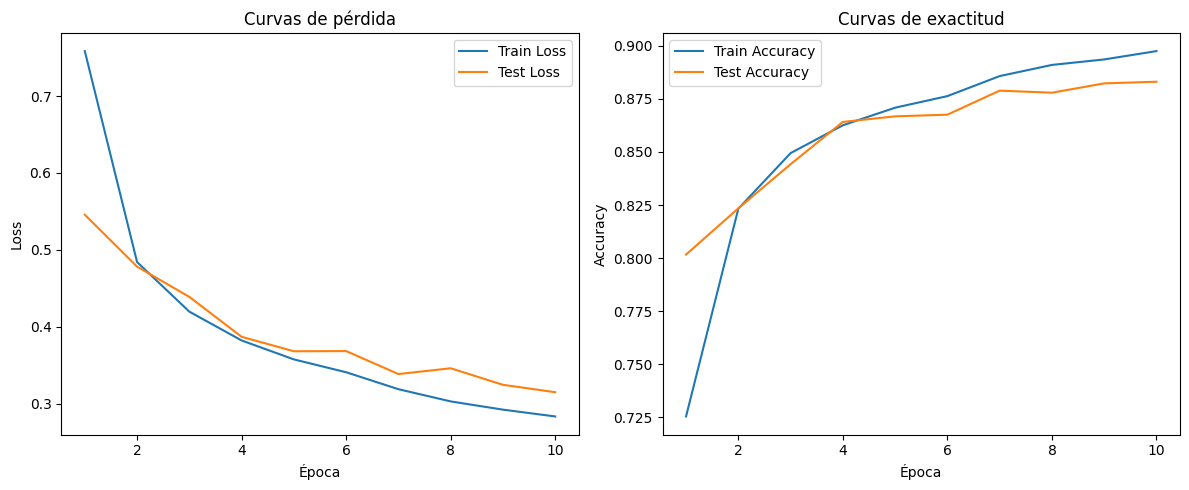

In [21]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 1) Modelo
model = lenet_mejorado().to(device)

# 2) Materializar capas Lazy
X_lote, _ = next(iter(iter_train))
X_lote = X_lote.to(device)

with torch.no_grad():
    _ = model(X_lote)

# 3) Inicializar pesos
model.apply(init_pesos)

# 4) Optimizador y función de pérdida
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# 5) Historial de métricas
hist = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

num_epochs = 10

for epoch in range(num_epochs):
    # -------------------------
    # Entrenamiento
    # -------------------------
    model.train()
    train_loss_sum = 0.0
    train_acc_sum = 0.0
    train_batches = 0

    for X, y in iter_train:
        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        preds = logits.argmax(dim=1)
        acc = (preds == y).float().mean().item()

        train_loss_sum += loss.item()
        train_acc_sum += acc
        train_batches += 1

    train_loss = train_loss_sum / train_batches
    train_acc = train_acc_sum / train_batches

    # -------------------------
    # Evaluación
    # -------------------------
    model.eval()
    test_loss_sum = 0.0
    test_acc_sum = 0.0
    test_batches = 0

    with torch.no_grad():
        for X, y in iter_test:
            X = X.to(device)
            y = y.to(device)

            logits = model(X)
            loss = criterion(logits, y)

            preds = logits.argmax(dim=1)
            acc = (preds == y).float().mean().item()

            test_loss_sum += loss.item()
            test_acc_sum += acc
            test_batches += 1

    test_loss = test_loss_sum / test_batches
    test_acc = test_acc_sum / test_batches

    # Guardar métricas
    hist["train_loss"].append(train_loss)
    hist["train_acc"].append(train_acc)
    hist["test_loss"].append(test_loss)
    hist["test_acc"].append(test_acc)

    print(
        f"Época {epoch+1}/{num_epochs} | "
        f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
        f"test_loss={test_loss:.4f} | test_acc={test_acc:.4f}"
    )

# 6) Graficar curvas
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# Subgráfico 1: pérdida
plt.subplot(1, 2, 1)
plt.plot(epochs, hist["train_loss"], label="Train Loss")
plt.plot(epochs, hist["test_loss"], label="Test Loss")
plt.title("Curvas de pérdida")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

# Subgráfico 2: exactitud
plt.subplot(1, 2, 2)
plt.plot(epochs, hist["train_acc"], label="Train Accuracy")
plt.plot(epochs, hist["test_acc"], label="Test Accuracy")
plt.title("Curvas de exactitud")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

**Pregunta de análisis:**

Observá las curvas de entrenamiento:

1. ¿Hay signos de *overfitting*? ¿Cómo se manifestaría en las curvas de pérdida y exactitud?
2. ¿Qué técnicas de regularización podrías agregar a la arquitectura para mejorar la generalización?

1. No hay signos de overfitting porque ambas curvas progresan muy de forma muy parecida


2. Podrigamos agregar:
    1.   Dropout
    2.   Batch normalization
    3.   Augmentation







---
## Sección G: Arquitecturas modernas — ResNet



El siguiente diagrama resume la arquitectura de **ResNet-34**, la variante con bloques básicos (dos convoluciones 3x3):

![img](https://i.imgur.com/5TiH4Qu.png)

| Símbolo | Significado |
|---|---|
| `7x7 conv, 64, /2` | Conv 7x7 — 64 canales de salida — stride 2 (capa de entrada) |
| `3x3 conv, C` | Conv 3x3 — C canales — stride 1 (dentro de un bloque) |
| Flecha curva sólida | Skip connection sin proyección (canales y stride no cambian) |
| Flecha curva punteada | Skip con proyección 1x1 (ajusta canales o stride al cambiar de grupo) |

### Ejercicio 12 — Implementar ResNet-34

**Objetivo:** Construir ResNet-34 componiendo los bloques auxiliares provistos, leyendo el diagrama de arquitectura para determinar los hiperparámetros de cada grupo.

**Contexto:**

Todas las piezas ya están implementadas en el setup: `ResidualBlock`, `Base`, `ResModule` y `ResNet`. Tu única tarea es completar `ResNet34`, que hereda de `ResNet` y le pasa la arquitectura correcta.

La clase `ResNet` recibe un argumento `arch`: una tupla de pares `(num_residuals, num_channels)` que describe cada grupo de bloques residuales. Por ejemplo, `((3, 64), (4, 128))` crearía dos grupos: el primero con 3 bloques de 64 canales y el segundo con 4 bloques de 128 canales.

**Enunciado:**

1. Completá la clase `ResNet34` usando el diagrama de arquitectura para determinar `arch`. La red tiene cuatro grupos de bloques con estas características:

| Grupo | Bloques residuales | Canales de salida |
|---|---|---|
| b2 | 3 | 64 |
| b3 | 4 | 128 |
| b4 | 6 | 256 |
| b5 | 3 | 512 |

2. Instanciá el modelo: `model = ResNet34()`.
3. Hacé un *forward pass* con una imagen de prueba de forma `(1, 3, 224, 224)` (tamaño típico de ImageNet) para materializar los módulos *lazy* y verificar que la salida tiene forma `(1, 10)`.
4. Contá el total de parámetros con `sum(p.numel() for p in model.parameters())`. ResNet-34 tiene aproximadamente **21 millones** de parámetros.

> **Pistas:**
> - `ResNet34` solo necesita implementar `__init__`: llamá a `super().__init__(arch, num_classes)` con la tupla correcta.
> - `ResNet` ya incluye la capa de entrada `Base`, los grupos `ResModule` y la cabeza de clasificación (`AdaptiveAvgPool -> Flatten -> Linear`). No tenés que agregar nada más.
> - El *forward pass* de prueba es necesario antes de contar parámetros porque los módulos `Lazy` no tienen pesos hasta que ven datos.

In [22]:
# --- Setup: bloques auxiliares de ResNet ----------------------------------
# Ejecutar esta celda sin modificar antes de implementar ResNet34.
import torch
import torch.nn as nn
import torch.nn.functional as F


class ResidualBlock(nn.Module):
    """Bloque residual basico: dos convoluciones 3x3 con conexion residual.

    Parametros:
    num_channels (int): canales de salida de ambas convoluciones
    use_1x1conv  (bool): si True, agrega una conv 1x1 en la skip (proyeccion)
    strides      (int): stride de la primera conv (y de la proyeccion si aplica)
    """
    def __init__(self, num_channels, use_1x1conv=False, strides=1):
        super().__init__()
        self.conv1 = nn.LazyConv2d(num_channels, kernel_size=3, padding=1, stride=strides)
        self.conv2 = nn.LazyConv2d(num_channels, kernel_size=3, padding=1)
        self.conv3 = nn.LazyConv2d(num_channels, kernel_size=1, stride=strides) if use_1x1conv else None
        self.bn1 = nn.LazyBatchNorm2d()
        self.bn2 = nn.LazyBatchNorm2d()

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3:
            X = self.conv3(X)  # proyeccion 1x1 para igualar dimensiones con Y
        Y += X
        return F.relu(Y)


class Base(nn.Module):
    """Capa de entrada de ResNet: Conv 7x7 (stride 2) + BN + ReLU + MaxPool (stride 2)."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.LazyConv2d(64, kernel_size=7, stride=2, padding=3),
            nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

    def forward(self, X):
        return self.net(X)


class ResModule(nn.Module):
    """Grupo de num_residuals bloques residuales.

    El primer bloque aplica stride=2 y proyeccion 1x1 (salvo en el primer grupo,
    donde el numero de canales ya fue ajustado por Base).

    Parametros:
    num_residuals (int): cantidad de bloques en el grupo
    num_channels  (int): canales de salida de todos los bloques
    first_module  (bool): True solo para el primer grupo (b2), no hace submuestreo
    """
    def __init__(self, num_residuals, num_channels, first_module=False):
        super().__init__()
        blk = []
        for i in range(num_residuals):
            if i == 0 and not first_module:
                blk.append(ResidualBlock(num_channels, use_1x1conv=True, strides=2))
            else:
                blk.append(ResidualBlock(num_channels))
        self.net = nn.Sequential(*blk)

    def forward(self, X):
        return self.net(X)


class ResNet(nn.Module):
    """ResNet generica configurable por arquitectura.

    Parametros:
    arch: tupla de (num_residuals, num_channels) por grupo de bloques
    num_classes (int): numero de clases de salida
    """
    def __init__(self, arch, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(Base())
        for i, b in enumerate(arch):
            self.net.add_module(f'b{i+2}', ResModule(*b, first_module=(i == 0)))
        self.net.add_module('last', nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),  # reduce a (C, 1, 1) sin importar el tamano de entrada
            nn.Flatten(),
            nn.LazyLinear(num_classes)))

    def forward(self, X):
        return self.net(X)

In [23]:
import torch

class ResNet34(ResNet):
    def __init__(self, num_classes=10):
        arch = (
            (3, 64),
            (4, 128),
            (6, 256),
            (3, 512),
        )
        super().__init__(arch, num_classes)

model = ResNet34()

# materializar capas Lazy
X = torch.randn(1, 3, 224, 224)
y = model(X)

print("Output shape:", y.shape)  # esperado: torch.Size([1, 10])

# contar parametros
total_params = sum(p.numel() for p in model.parameters())
print("Total params:", total_params)

Output shape: torch.Size([1, 10])
Total params: 21296522


**Pregunta de análisis:**

1. ¿Por qué la skip connection garantiza que el gradiente fluya hacia atrás incluso cuando el bloque residual aprende poco? Expresá la idea en términos de la derivada de la salida respecto de la entrada $x$.

  Porque en la salida derivada de y=F(x)+x aunque la derivada de F(x) sea un valor muy chico, siempre le vamos a poder sumar la derivad de x respecto de sí misma, o sea sumar un 1.


2. ¿Qué rol cumple la convolución 1x1 de proyección en el primer bloque de cada grupo? ¿Por qué no hace falta en los bloques siguientes del mismo grupo?

El rol que cumple es hacer compatibles el tamaño de salida y de la entrada

---
## ¡Listo!

Completaste el Laboratorio 2. Implementaste la convolución desde cero, entrenaste un kernel con gradiente descendente, dominaste los parámetros que controlan las dimensiones espaciales (kernel, padding y stride), contaste parámetros de capas convolucionales, entrenaste tu primera CNN completa sobre Fashion-MNIST y construiste ResNet-34 usando conexiones residuales. En el próximo laboratorio exploraremos técnicas de regularización y transfer learning.